# Error mitigation using the Estimator and Sampler primitives

## Table of Contents

* [0. Background](#background)
* [1. Requirements](#requirements)
* [2. Error Mitigation and Suppression techniques applied to the Estimator](#estimator)
    * [2.1 Step 1. Map classical inputs to a quantum problem](#step1)
        - [2.1.1 Mirror circuit](#mirror)
    * [2.2. Step 2. Optimize circuits for quantum hardware execution](#step2)
    * [2.3. Step 3. Execute circuits using the Estimator primitive](#step3)
    * [2.4. Step 4. Post-process and return results in classical format](#step4)
    * [2.5. Scale the experiment up](#scale)
        - [2.5.1 Execute the circuit for 60 qubits](#execute60)
        - [2.5.2 Post-process for 60 qubits](#postprocess60)
* [3. Error suppression and mitigation using the Sampler](#sampler)
    - [3.1 Create the 60 qubits circuit for the Sampler](#create60)
    - [3.2 Execute the circuit for 60 qubits using Error Suppression](#execute60sampler)
    - [3.3 Post-process for 60 qubits](#postprocess60sampler)
* [4. Using M3 readout mitigation method](#m3)
* [5. Conclusion](#conclusion)

## 0. Background <a id="background"></a>

In this notebook, you'll explore the error suppression and error mitigation options available with the Estimator and Sampler primitives from Qiskit Runtime. You will construct a circuit and observable and submit jobs using the Estimator and Sampler primitives using different combinations of error mitigation settings. Then, you will plot the results to observe the effects of the various settings. Most of the notebook uses a 6-qubit circuit to make visualizations easier, and at the end, you can scale up the workflow to 60 qubits.

These are the error suppression and mitigation options you will use:

* [Overview of all options](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/options)
* [Dynamical decoupling](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.options.DynamicalDecouplingOptions)
* [Resilience, including measurement error mitigation and zero-noise extrapolation (ZNE)](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.options.ResilienceOptionsV2)
* [Twirling](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.options.TwirlingOptions)
* [Probabilistic Error Cancellation](https://quantum.cloud.ibm.com/docs/en/guides/error-mitigation-and-suppression-techniques#probabilistic-error-cancellation-pec)
* [M3: Matrix‑free Measurement Mitigation](https://qiskit.github.io/qiskit-addon-mthree/)

## 1. Requirements <a id="requirements"></a>

Before starting this notebook, ensure that you have the following installed:

* Qiskit SDK 2.1 or later with visualization support (`pip install 'qiskit[visualization]'`)
* Qiskit Runtime 0.40 or later (`pip install qiskit-ibm-runtime`)
* Qiskit Aer 0.17 (`pip install qiskit-aer`)
* mthree library 3.0.0 (`pip install mthree`)


In [1]:
# %pip install qiskit
# %pip install qiskit[visualization]
# %pip install qiskit-ibm-runtime
# %pip install qiskit-aer
# %pip install pylatexenc
# %pip install mthree

## 2. Error Mitigation and Suppression techniques applied to the Estimator

### 2.1 Step 1. Map classical inputs to a quantum problem <a id="step1"></a>

This notebook assumes that the classical problem has already been mapped to quantum. Begin by constructing a circuit and observable to measure. While the techniques used in this notebook apply to many different kinds of circuits, for simplicity this notebook uses the [`efficient_su2`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.efficient_su2) circuit included in Qiskit's circuit library.

`efficient_su2` is a parameterized quantum circuit designed to be efficiently executable on quantum hardware with limited qubit connectivity, while still being expressive enough to solve problems in application domains like optimization and chemistry. It's built by alternating layers of parameterized single-qubit gates with a layer containing a fixed pattern of two-qubit gates, for a chosen number of repetitions. The pattern of two-qubit gates can be specified by the user. Here you can use the built-in `pairwise` pattern because it minimizes the circuit depth by packing the two-qubit gates as densely as possible. This pattern can be executed using only linear qubit connectivity.


<div class="alert alert-block alert-success">

#### **Ex1: Create an Efficient SU2 Circuit**

Build a 6-qubit quantum circuit using the efficient_su2 template with 5 repetitions and pairwise entanglement pattern. Set the global phase to 0 and visualize it.

**References:**
- [efficient_su2 circuit](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.efficient_su2)
- [Circuit visualization](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.QuantumCircuit#draw)

</div>

In [ ]:
# Create a circuit that implements the Efficient SU2 ansatz with 6 qubits, 5 repetition and pairwise entanglement.
from qiskit.circuit.library import efficient_su2

### YOUR CODE HERE
circuit = 
circuit.decompose().global_phase = 0
circuit.draw("mpl", fold=-1 ,scale=0.4)



For our observable, let's take the Pauli $Z$ operator acting on the first qubit, $Z I I I I I$.

<div class="alert alert-block alert-success">

#### **Ex2: Create a Multi-Qubit Observable**

Construct an observable consisting of a Pauli Z operator applied to only the first qubit. Use `SparsePauliOp` to represent it as a string of Z and I operators and print the result.

**References:**
- [SparsePauliOp](https://docs.quantum.ibm.com/api/qiskit/qiskit.quantum_info.SparsePauliOp)

</div>

In [ ]:
# Create an observable using SparsePauliOp
from qiskit.quantum_info import SparsePauliOp



### YOUR CODE HERE
num_qubits =
# Define pauli_string as 'Z' + 'I' * (num_qubits -1)
pauli_string = 
# Create the observable and print it
observable = 
print(observable)

At this point, you could proceed to run your circuit and measure the observable. However, you also want to compare the output of the quantum device with the correct answer - that is, the theoretical value of the observable, if the circuit had been executed without error. For small quantum circuits you can calculate this value by simulating the circuit on a classical computer, but this is not possible for larger, utility-scale circuits. You can work around this issue with the "mirror circuit" technique (also known as "compute-uncompute"), which is useful for benchmarking the performance of quantum devices.

#### 2.1.1 Mirror circuit <a id="mirror"></a>

In the mirror circuit technique, you concatenate the circuit with its inverse circuit, which is formed by inverting each gate of the circuit in reverse order. The resulting circuit implements the identity operator, which can trivially be simulated. Because the structure of the original circuit is preserved in the mirror circuit, executing the mirror circuit still gives an idea of how the quantum device would perform on the original circuit.

The following code cell assigns random parameters to your circuit, and then constructs the mirror circuit using the [`unitary_overlap`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.unitary_overlapp) class. Before mirroring the circuit, append a [barrier](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.Barrier#barrier) instruction to it to prevent the transpiler from merging the two parts of the circuit on either side of the barrier. Without the barrier, the transpiler would merge the original circuit with its inverse, resulting in a transpiled circuit without any gates.


<div class="alert alert-block alert-success">

#### **Ex3: Construct a Mirror Circuit**

Build a mirror circuit (compute-uncompute) by: (1) generating random parameters and assigning them to your circuit, (2) adding a barrier to prevent transpiler optimization, (3) constructing the unitary overlap, and (4) visualizing the result.

**References:**
- [assign_parameters](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#assign_parameters)
- [Barrier instruction](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.Barrier)
- [unitary_overlap](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.unitary_overlap)


</div>

In [ ]:
import numpy as np
from qiskit.circuit.library import unitary_overlap

# Generate random parameters
rng = np.random.default_rng(1234)
params = rng.uniform(-np.pi, np.pi, size=circuit.num_parameters)

### YOUR CODE HERE
# Assign the parameters to the circuit
assigned_circuit = 
# Add a barrier() to prevent circuit optimization during transpilation

# Construct the mirror circuit using unitary_overlap
mirror_circuit = 
# Visualize the mirror circuit
mirror_circuit.draw("mpl", fold=-1,scale=0.4)


### 2.2. Step 2: Optimize circuits for quantum hardware execution <a id="step2"></a>

You must optimize your circuit before running it on hardware. This process involves a few steps:

* Pick a qubit layout that maps the virtual qubits of your circuit to physical qubits on the hardware.
* Insert swap gates as needed to route interactions between qubits that are not connected.
* Translate the gates in your circuit to [Instruction Set Architecture (ISA)](https://docs.quantum.ibm.com/transpile#instruction-set-architecture) instructions that can directly be executed on the hardware.
* Perform circuit optimizations to minimize the circuit depth and gate count.

The transpiler built into Qiskit can perform all of these steps for you. Because this notebook uses a hardware-efficient circuit, the transpiler should be able to pick a qubit layout that does not require any swap gates to be inserted for routing interactions.

You need to choose the hardware device to use before you optimize your circuit. The following code cell requests the least busy device with at least 156 qubits.


In [62]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Choose a real backend
service = QiskitRuntimeService(channel='ibm_quantum_platform',)
backend = service.least_busy(min_num_qubits=156)
# print backend details
print(
    f"Name: {backend.name}\n"
    f"Version: {backend.backend_version}\n"
    f"No. of qubits: {backend.num_qubits}\n"
    f"Processor type: {backend.processor_type}\n"
)
# Replace with a specifc backend if you desire
#backend =service.backend("ibm_pittsburgh")  

Name: ibm_kingston
Version: 1.0.0
No. of qubits: 156
Processor type: {'family': 'Heron', 'revision': '2'}



You can use a [noisy simulator](https://quantum.cloud.ibm.com/docs/en/guides/local-testing-mode) first to make sure you understand the workflows before executing it on real hardware.

In [ ]:
# option to use the AerSimulator instead of a real quantum device
from qiskit_aer import AerSimulator
backend = AerSimulator.from_backend(backend)

You can transpile your circuit for your chosen backend by creating a pass manager and then running the pass manager on the circuit. An easy way to create a pass manager is to use the [`generate_preset_pass_manager`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/transpiler_preset) function. See [Transpile with pass managers](https://docs.quantum.ibm.com/transpile/transpile-with-pass-managers) for a more detailed explanation of transpiling with pass managers.


<div class="alert alert-block alert-success">

#### **Ex4: Transpile Circuit for Hardware**

Generate a preset pass manager with optimization level 3 and apply it to your mirror circuit to create an ISA-compatible circuit. Then visualize the transpiled circuit to see the decomposed gates.

**References:**
- [generate_preset_pass_manager](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.transpiler.generate_preset_pass_manager)
- [Transpilation guide](https://docs.quantum.ibm.com/transpile/index)
- [Pass managers](https://docs.quantum.ibm.com/transpile/transpile-with-pass-managers)

</div>

In [ ]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
### YOUR CODE HERE
# Generate the pass manager with optimization level 3
pm = 
# Transpile the circuit using the pass manager
isa_circuit = 
# Visualize the circuit
isa_circuit.draw("mpl", scale=0.7,fold=-1,idle_wires=False)

The transpiled circuit now contains only ISA instructions. The single-qubit gates have been decomposed in terms of $\sqrt{X}$ gates and $R_z$ rotations, and the CX gates have been decomposed into [ECR gates](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.ECRGate#ecrgate) and single-qubit rotations.

The transpilation process has mapped the virtual qubits of the circuit to physical qubits on the hardware. The information about the qubit layout is stored in the `layout` attribute of the transpiled circuit. The observable was also defined in terms of the virtual qubits, so you need to apply this layout to the observable, which you can do with the [`apply_layout`](https://docs.quantum.ibm.com/api/qiskit/qiskit.quantum_info.SparsePauliOp#apply_layout) method of `SparsePauliOp`.


<div class="alert alert-block alert-success">

#### **Ex5: Apply Layout to Observable**

Apply the qubit layout mapping from the transpiled ISA circuit to your original observable using the `apply_layout()` method. Print both the original and ISA-mapped observables to understand the physical qubit mapping.

**References:**
- [SparsePauliOp.apply_layout()](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.SparsePauliOp#apply_layout)
- [QuantumCircuit.layout](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#layout)

</div>

In [ ]:
# Apply the layout from isa_circuit to the original observable using apply_layout()
# Print both original and ISA observables to see the difference

### YOUR CODE HERE
# Apply the layout from isa_circuit to the original observable using apply_layout()
isa_observable = 
print("Original Observable:", observable)
print("ISA Observable:", isa_observable)

### 2.3. Step 3. Execute circuits using the Estimator primitive <a id="step3"></a>

You are now ready to run your circuit using the Estimator primitive.

Here you will submit six separate jobs, starting with no error suppression or mitigation, and successively enabling various error suppression and mitigation options available in Qiskit Runtime. For information about the options, refer to the following pages:

* [Overview of all options](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/options)
* [Dynamical decoupling](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.options.DynamicalDecouplingOptions)
* [Resilience, including measurement error mitigation and zero-noise extrapolation (ZNE)](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.options.ResilienceOptionsV2)
* [Twirling](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.options.TwirlingOptions)
* [Probabilistic Error Cancellation](https://quantum.cloud.ibm.com/docs/en/guides/error-mitigation-and-suppression-techniques#probabilistic-error-cancellation-pec)

Because these jobs can run independently of each other, you can use [batch mode](https://docs.quantum.ibm.com/run/run-jobs-batch) to allow Qiskit Runtime to optimize the timing of their execution.


<div class="alert alert-block alert-success">

#### **Ex6: Implement the Estimator Workflow Function**

Implement `run_estimator_workflow()` function that: (1) transpiles circuit and observable, (2) creates 6 jobs progressively enabling mitigation options (no mitigation → DD → TREX → twirling → ZNE → PEC), (3) retrieves results and extracts expectation values and standard errors, (4) returns the arrays of values and errors.

**References:**
- [EstimatorV2](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.EstimatorV2)
- [Batch mode](https://docs.quantum.ibm.com/run/run-jobs-batch)
- [Dynamical Decoupling](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.options.DynamicalDecouplingOptions)
- [Resilience Options (ZNE, TREX, PEC)](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.options.ResilienceOptionsV2)
- [Twirling Options](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.options.TwirlingOptions)
- [Error Mitigation Guide](https://docs.quantum.ibm.com/guides/error-mitigation-and-suppression-techniques)

</div>

In [ ]:
from qiskit_ibm_runtime import Batch, EstimatorV2 as Estimator
from qiskit.transpiler import CouplingMap

# Define a function to run the Estimator workflow with different error mitigation options
# Input: circuit, observable, backend
# Output: tuple of (expectation_vals, standard_errors)
def run_estimator_workflow(circuit, observable, backend):
   """
    Transpile circuit and observable, then execute 6 jobs with progressively
    enabled error mitigation/suppression techniques.
    
    Students: Implement this function to:
    1. Transpile the circuit and observable
    2. Create 6 jobs in a Batch with the following configurations:
       - Job 0: No mitigation
       - Job 1: Add dynamical decoupling (DD)
       - Job 2: Add readout error mitigation (TREX)
       - Job 3: Add gate twirling
       - Job 4: Add zero-noise extrapolation (ZNE)
       - Job 5: Add probabilistic error cancellation (PEC)
    3. Retrieve results and extract expectation values and standard errors
    4. Return (expectation_vals, standard_errors)
   """
   ### YOUR CODE HERE
   # 1. Transpile
   pm = 
   isa_circuit = 
   isa_observable = 
    
   pub = (isa_circuit, isa_observable)
   jobs = []
   # 2. Create Batch with 6 jobs
   with Batch(backend=backend) as batch:
      estimator = Estimator(mode=batch)
      estimator.options.default_shots = 1000
      # 2.1 No mitigation

      # 2.2. DD

      # 2.3 TREX

      # 2.4 Gate Twirling

      # 2.5 ZNE

      # 2.6 PEC 

      # If you use a simulator you will need to uncomment these lines to run PEC
      if isinstance(backend, AerSimulator):
         estimator.options.simulator = {"coupling_map": CouplingMap.from_full(backend.configuration().n_qubits)}
   
   # 3. Retrieve results
   results = [job.result() for job in jobs]
   pub_results = [result[0] for result in results]
   # 4. Extract expectation values and standard errors
   expectation_vals = np.array([float(pub_result.data.evs) for pub_result in pub_results])
   standard_errors = np.array([float(pub_result.data.stds) for pub_result in pub_results])
   return expectation_vals, standard_errors
    


### 2.4. Step 4. Post-process and return results in classical format <a id="step4"></a>

Finally, you can analyze the data. Here you will retrieve the job results, extract the measured expectation values from them, and plot the values, including error bars of one standard deviation.

Note: The 6-qubit exercise is intended to be run on a simulator backend. If you run it on quantum hardware instead, the expected execution time is approximately the value shown below.

<div class="alert alert-block alert-warning">
    
*Usage estimate: 2 minutes and 53 seconds on an Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in the [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*
</div>

In [ ]:
import matplotlib.pyplot as plt

# For 6 qubits: Call the function to run the Estimator workflow
expectation_vals, standard_errors = run_estimator_workflow(mirror_circuit, observable, backend)

# Plot the expectation values
fig, ax = plt.subplots()
labels = ["No mitigation", "+ DD", "+ TREX", "+ Twirling", "+ ZNE", "+ PEC"]
ax.bar(range(len(labels)), expectation_vals, yerr=standard_errors, label="experiment")
ax.axhline(y=1.0, color="gray", linestyle="--", label="ideal")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_ylabel("Expectation value")
ax.legend(loc="lower right")

plt.show()

Because a mirror quantum circuit applies a sequence of operations followed by their inverse, its overall effect is the identity operation. Therefore, when calculating the expectation value of the chosen observable, we expect to obtain a value of 1 in the ideal, noise-free case.

$$
\langle \psi|\hat{O}|\psi \rangle = \langle \psi|Z\otimes I^{\otimes n-1}|\psi \rangle = \langle 0|U_{mirror}^\dagger Z\otimes U_{mirror}| 0 \rangle = \langle 0|I^{\otimes n} Z I^{\otimes n}| 0 \rangle = \langle 0| Z | 0 \rangle = 1 \langle 0 | 0 \rangle  =1
$$

At this small scale, it is difficult to see the effect of most of the error mitigation techniques, but zero noise extrapolation (ZNE) typically does give a noticeable improvement. On the other hand, note that probabilistic error cancellation (PEC) result has a larger error bar.

### 2.5. Scale the experiment up <a id="scale"></a>

When developing an experiment, it's useful to start with a small circuit to make visualizations and simulations easier. Now that you've developed and tested our workflow on a 6-qubit circuit, you can scale it up to 60 qubits. The following code cell repeats all of the steps in this notebook, but now applies them to a 60-qubit circuit.


<div class="alert alert-block alert-success">

#### **Ex7: Create 60-Qubit Circuit, Observable, and Mirror**

Scale up the workflow to 60 qubits by: (1) creating an efficient_su2 circuit with 60 qubits and 1 repetition, (2) creating a 60-qubit Z^⊗60 observable, (3) assigning random parameters, adding barrier, and constructing the mirror circuit.

**References:**
- [efficient_su2 circuit](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.efficient_su2)
- [SparsePauliOp](https://docs.quantum.ibm.com/api/qiskit/qiskit.quantum_info.SparsePauliOp)
- [unitary_overlap](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.unitary_overlap)

</div>

In [ ]:
# Repeat the workflow for 60 qubits:
# Create the circuit and observable for 60 qubits
num_qubits = 60

### YOUR CODE HERE: Create efficient_su2 circuit with num_qubits=60, reps=1, entanglement='pairwise'
### YOUR CODE HERE: Create SparsePauliOp observable with 'Z' + 'I'* 59
### YOUR CODE HERE: Assign random parameters and construct mirror circuit with barrier

#### 2.5.1 Execute the circuit for 60 qubits <a id="execute60"></a>

If you have successfully built the 60-qubit circuit, consider running it on quantum hardware. Simulating a circuit of this size with a statevector simulator is generally unfeasible due to the exponential growth in computational resources required.

In [ ]:
### YOUR CODE HERE
# Choose the backend you want to use to execute the 60-qubit circuit
backend = 

<div class="alert alert-block alert-warning">

*Usage estimate: 2 minutes and 56 seconds on an Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in the [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*
</div>

In [ ]:
# For 60 qubits: Call the same function with the 60-qubit circuit and observable
expectation_vals_60q, standard_errors_60q = run_estimator_workflow(mirror_circuit, observable, backend)

#### 2.5.2 Post-process for 60 qubits <a id="postprocess60"></a>

In [ ]:
# Plot the expectation values for 60 qubits
fig, ax = plt.subplots()
labels = ["No mitigation", "+ DD", "+ TREX", "+ Twirling", "+ ZNE", "+ PEC"]
ax.bar(range(len(labels)), expectation_vals_60q, yerr=standard_errors_60q, label="experiment")
ax.axhline(y=1.0, color="gray", linestyle="--", label="ideal")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_ylabel("Expectation value for 60 qubits")
ax.legend(loc="lower right")

plt.show()

When you compare the 60-qubit results with the 6-qubit results from earlier, you might note the following (your results might differ across runs):

* The results without error mitigation are worse. Running the larger circuit involves executing more gates, so there are more opportunities for errors to accumulate.
* The addition of dynamical decoupling might have worsened performance. This is not surprising, because the circuit is very dense. Dynamical decoupling is primarily useful when there are large gaps in the circuit during which qubits sit idle without gates being applied to them. When these gaps are not present, dynamical decoupling is not effective, and can actually worsen performance due to errors in the dynamical decoupling pulses themselves. The 6-qubit circuit may have been too small for us to observe this effect.
* With zero-noise extrapolation, the result is as good, or nearly as good, as the 6-qubit result. This demonstrates the power of the ZNE technique!
* The probabilistic error cancellation (PEC) technique is giving a better result than in the 6 qubit scenario. However further tuning of the parameters is needed to perform as good as ZNE in this specific circuit.
* If you want to learn more about these techniques you can check out [this material](https://github.ibm.com/Coding-Challenges-Squad/QGSS-2025-labs/blob/main/lab-2/Lab2_sol.ipynb) about transpilation and error mitigation


## 3. Error suppression and mitigation using the Sampler <a id="sampler"></a>

The Qiskit Runtime Sampler primitive does not support error mitigation techniques yet. However it supports error suppression techniques and we are going to test how you can use them to try to prevent errors from occurring. To apply error mitigation for sampling we will use later the M3 Qiskit Addon.

First, we will apply dynamical decoupling and twirling options.

### 3.1 Create the 60 qubits circuit for the Sampler

<div class="alert alert-block alert-success">

#### **Ex8: Prepare Circuit for Sampler with Measurements**

Create a sampler-ready circuit by: (1) copying the 60-qubit mirror circuit, (2) adding measurements to all qubits using `measure_all()`, and (3) transpiling it using the preset pass manager.

**References:**
- [QuantumCircuit.measure_all()](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.QuantumCircuit#measure_all)
- [generate_preset_pass_manager](https://docs.quantum.ibm.com/api/qiskit/qiskit.transpiler.preset_passmanagers.generate_preset_pass_manager)
- [SamplerV2](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.SamplerV2)

</div>

In [ ]:
### YOUR CODE HERE
# Add measurements to the mirror_circuit_60q using measure_all()

# Transpile using pm_sampler pass manager to create isa_circuit_sampler
pm_sampler = 
isa_circuit_sampler = 

### 3.2 Execute the circuit for 60 qubits using Error Suppression <a id="execute60sampler"></a>

<div class="alert alert-block alert-success">

#### **Ex9: Execute Sampler Jobs with Error Suppression**

Submit 3 sampler jobs in a batch: (1) Job 0 with no suppression, (2) Job 1 with gate twirling enabled (num_randomizations="auto"), (3) Job 2 with both gate twirling and dynamical decoupling (sequence_type="XpXm"). Retrieve and store results.

**References:**
- [SamplerV2](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.SamplerV2)
- [Batch mode](https://docs.quantum.ibm.com/run/run-jobs-batch)
- [Twirling Options](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.options.TwirlingOptions)
- [Dynamical Decoupling](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.options.DynamicalDecouplingOptions)

</div>

As before, you can run this on a simulator first and then on real hardware

In [ ]:
### YOUR CODE HERE
# Define an AerSimulator backend for the first run and then a real hardware backend
backend = 

<div class="alert alert-block alert-warning">

*Usage estimate: 8 seconds on an Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in the [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*
</div>

In [ ]:
from qiskit_ibm_runtime import Batch, SamplerV2 as Sampler

# Create primitive input
pub = isa_circuit_sampler  # Just the circuit, no observable for Sampler

jobs_sampler = []

with Batch(backend=backend) as batch:
    sampler = Sampler(mode=batch)
    
    # Set number of shots
    sampler.options.default_shots = 1000

    # Job 0: Run with no error suppression
    ### YOUR CODE HERE: Submit job0_sampler
    
    # Job 1: Enable gate twirling
    ### YOUR CODE HERE: Enable twirling with num_randomizations="auto" and submit job1_sampler
    
    # Job 2: Enable dynamical decoupling (DD) in addition to gate twirling
    ### YOUR CODE HERE: Enable DD with sequence_type="XpXm" and submit job2_sampler


# After the batch, retrieve the results
results_sampler = [job_sampler.result() for job_sampler in jobs_sampler]

### 3.3 Post-process for 60 qubits <a id="postprocess60sampler"></a>

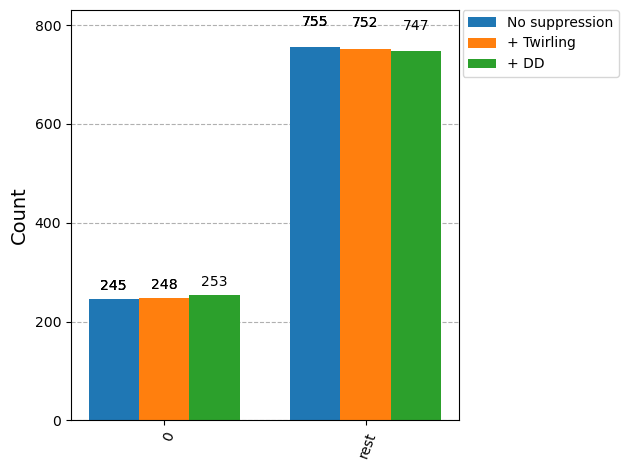

In [73]:
def convert_keys_to_decimal(counts_dict):
    return {int(bitstring, 2): count for bitstring, count in counts_dict.items()}
# Extract  counts
counts_list= [res[0].data.meas.get_counts() for res in results_sampler]
# Convert binary keys to decimal
decimal_counts_list = [convert_keys_to_decimal(d) for d in counts_list]

from qiskit.visualization import plot_histogram

# Labels for each configuration
labels = ["No suppression", "+ Twirling", "+ DD",]

# Plot all histograms together
plot_histogram(decimal_counts_list, number_to_keep=1, legend=labels)

In this plot, we can observe two key points (your results may vary across runs):

First, the application of error suppression techniques (DD and gate twirling) increases the probability of measuring the $|0\rangle^{\otimes n}$ state compared to all other states. This indicates that these techniques are effectively supressing the noise and improving the performance.

Second, we notice something that might seem counterintuitive at first: for the case of $n = 60$ qubits, the total counts for non-$|0\rangle^{\otimes n}$ states actually exceed those of the $|0\rangle^{\otimes n}$ state. However, this behavior is actually expected. In such a large Hilbert space (of dimension $2^{60}$) even low levels of noise can populate a vast number of excited states, making it common to see many non-zero bitstrings in the measurements. Still, the $|0\rangle^{\otimes n}$ state remains the most probable state, standing out clearly from the rest.

To confirm this, we can plot the 10 most frequently measured quantum states in the case without error suppression.

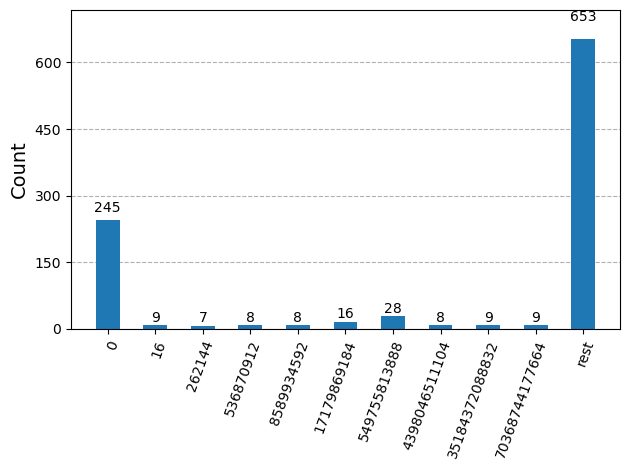

In [74]:
plot_histogram(decimal_counts_list[0], number_to_keep=10)

As we were expecting, the $|0\rangle^\otimes{n}$ state is the most frequently observed outcome. The presence of counts for other states is due to noise in the quantum device. However, the noise level is not too severe, as we are still able to clearly identify the most probable quantum state.

## 4. Using M3 readout mitigation method <a id="m3"></a>


The M3 ([Matrix‑free Measurement Mitigation](https://qiskit.github.io/qiskit-addon-mthree/)) method is a scalable approach to readout error mitigation that avoids constructing the full $2^n \times 2^n$ assignment matrix by using simplified models of readout errors. It assumes that correlations of order three and higher are negligible, which allows it to rely only on single-qubit and two-qubit assignment matrices obtained by preparing all qubits in the $\lvert 0\ldots0\rangle$ and $\lvert 1\ldots1\rangle$ states and measuring their error rates. These small $2\times2$ and $4\times4$ matrices are stored and later combined to form an effective mitigation matrix that is built only from the bitstrings observed during sampling. Because the size of this effective matrix grows with the number of sampled outcomes rather than $2^n$, M3 can be applied to circuits with much longer bitstrings than traditional linear algebra methods.

Now we are going to see how we can use it to reduce the error in the previous sampling exercise. For a more in-depth analysis check it out [here](https://quantum.cloud.ibm.com/docs/en/tutorials/readout-error-mitigation-sampler).

You might need to install this Qiskit Addon uncommenting the following line.

In [75]:
# %pip install mthree

We now repeat the same workflow as above, but with M3 calibration integrated into the job preparation stage, so that all jobs are properly calibrated before execution on the quantum device.

<div class="alert alert-block alert-success">

#### **Ex10: Apply M3 Readout Error Mitigation**

Implement M3 mitigation workflow: (1) get measurement map using `m3utils.final_measurement_mapping()`, (2) create M3Mitigation object, (3) run calibration with `cals_from_system()` in batch mode, (4) submit 3 sampler jobs (no suppression, twirling, DD+twirling), (5) apply M3 correction with `mthree.M3Mitigation.apply_correction()` on measurement counts, (6) convert quasi-probabilities to dictionaries.

**References:**
- [M3 Mitigation Documentation](https://qiskit.github.io/qiskit-addon-mthree/)
- [mthree.M3Mitigation](https://qiskit.github.io/qiskit-addon-mthree/apidocs/generated/mthree.M3Mitigation.html)
- [m3utils.final_measurement_mapping](https://qiskit.github.io/qiskit-addon-mthree/apidocs/generated/mthree.utils.final_measurement_mapping.html)
- [mthree.M3Mitigation.apply_correction](https://qiskit.github.io/qiskit-addon-mthree/stubs/mthree.M3Mitigation.html#mthree.M3Mitigation.apply_correction)
- [Readout Error Mitigation Tutorial](https://docs.quantum.ibm.com/guides/readout-error-mitigation)

</div>

As before, you can run this on a simulator first and then on real hardware

In [ ]:
### YOUR CODE HERE
# Define an AerSimulator backend for the first run and then a real hardware backend
backend = 

<div class="alert alert-block alert-warning">

*Usage estimate: 11 seconds on an Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in the [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*
</div>

In [ ]:
# M3 imports 
import mthree
import mthree.utils as m3utils

# Determine which physical qubits correspond to measured classical bits
### YOUR CODE HERE: Get meas_map using m3utils.final_measurement_mapping()

jobs_sampler = []
with Batch(backend=backend) as batch:
    sampler = Sampler(mode=batch)
    sampler.options.environment.job_tags = []
    # Set number of shots for your circuit sampling
    sampler.options.default_shots = 1000

    # Build mitigator and run M3 calibration inside same Batch
    ### YOUR CODE HERE: Create M3Mitigation object with backend
    ### YOUR CODE HERE: Run cals_from_system with meas_map, shots=1000, runtime_mode=batch

    # Job 0: Run with no error suppression
    ### YOUR CODE HERE: Submit job0_sampler
    
    # Job 1: Enable gate twirling
    ### YOUR CODE HERE: Enable twirling with num_randomizations="auto" and submit job1_sampler
    
    # Job 2: Enable dynamical decoupling (DD) in addition to gate twirling
    ### YOUR CODE HERE: Enable DD with sequence_type="XpXm" and submit job2_sampler

# After the batch, retrieve the results
results_sampler = [job_sampler.result() for job_sampler in jobs_sampler]
counts_list = [res[0].data.meas.get_counts() for res in results_sampler]

# Apply M3 correction to each result
### YOUR CODE HERE: Apply M3 correction using mit.apply_correction() for each entry in counts_list
### YOUR CODE HERE: Convert M3 quasi-probabilities to dicts


In [ ]:
shots = 1000
def convert_counts_list(list_of_dicts, shots=1000):
    return [
        {int(k): (int(round(float(v) * shots)) if float(v) >= 0 else 0)
         for k, v in d.items()}
        for d in list_of_dicts
    ]
decimal_m3_dicts_converted = convert_counts_list(decimal_m3_dicts, shots=shots)

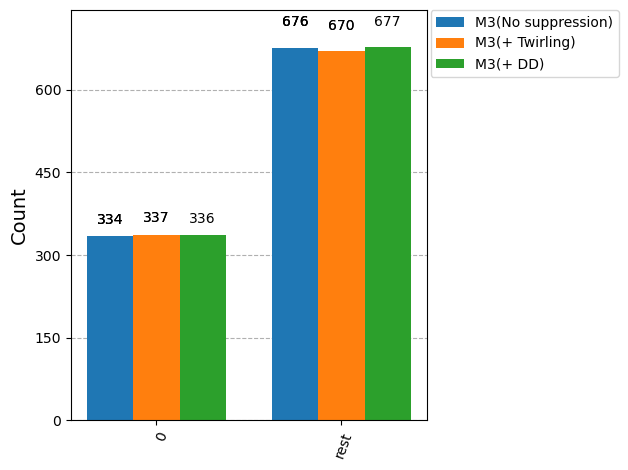

In [78]:
plot_histogram(decimal_m3_dicts_converted, number_to_keep=1, legend=labels_m3)


We can see that using the M3 Qiskit Addon significantly improves the results compared to the previous case without mitigation. 

On the other hand, once M3 error mitigation is applied, the effect of the suppression techniques becomes much less important.

## 5. Conclusion <a id="conclusion"></a>

In this notebook, you investigated different error mitigation options available for the Qiskit Runtime Estimator and Sampler primitives. You developed a workflow using a 6-qubit circuit with the Estimator, then scaled it up to 60 qubits. You also explored error suppression and mitigation techniques using the Sampler primitive, and the M3 (Matrix-free Measurement Mitigation) readout mitigation method. You might have observed that enabling more error suppression and mitigation options doesn't always improve performance (specifically, enabling dynamical decoupling in this case). However, strategic configuration choices can significantly enhance accuracy. As you apply these techniques to your own quantum computations, experiment with different option combinations to find the optimal configuration for your specific problems!